In [ ]:
#Data Ingesting
import pandas as pd
df = pd.read_csv(r"/content/olist_customers_dataset.csv")
cols_dont_needed =['order_id','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','customer_id','order_status','order_purchase_timestamp','customer_unique_id','order_approved_at','product_id','seller_id','customer_zip_code_prefix','shipping_limit_date','review_comment_message']
df.drop(columns=cols_dont_needed,inplace=True)
df.dropna(inplace=True)

In [ ]:
columns=df.columns
columns

Index(['payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_city', 'customer_state', 'order_item_id',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'review_score'],
      dtype='object')

In [ ]:
null_count=df.isnull().sum()
null_count

,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0
customer_city,0
customer_state,0
order_item_id,0
price,0
freight_value,0
product_category_name,0


Text(0, 0.5, 'count of the null values')

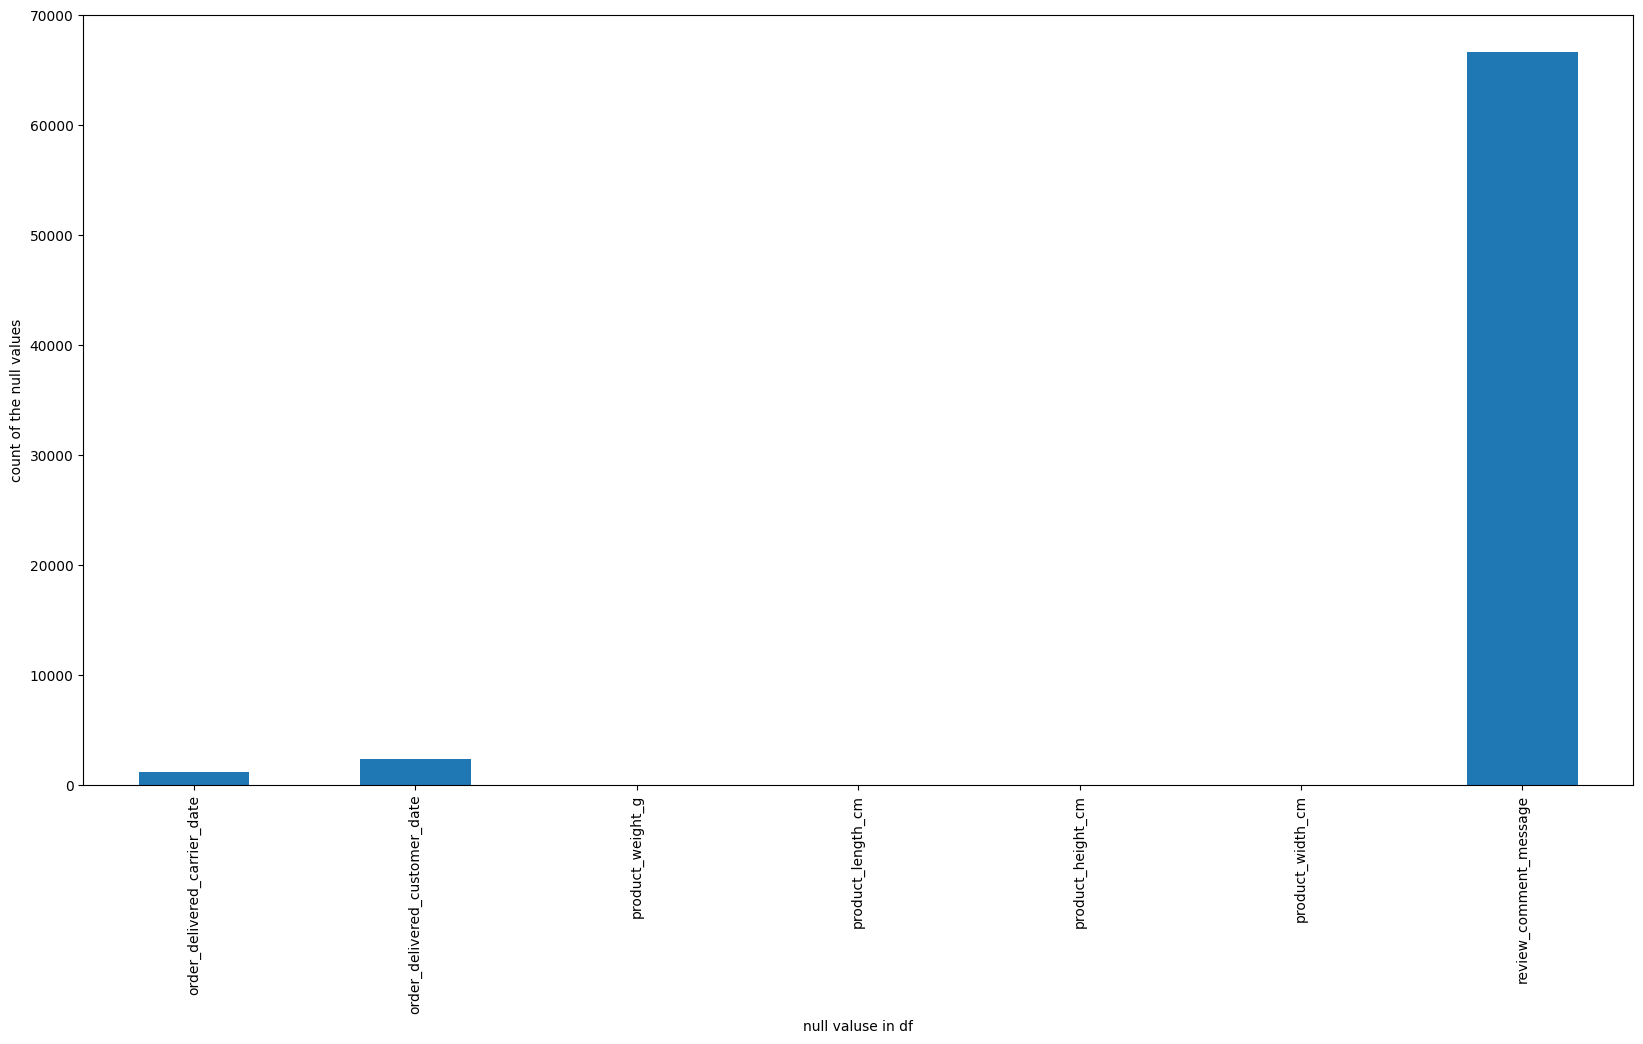

In [ ]:
import matplotlib.pyplot as plt

null_count[null_count>0].plot(kind= 'bar',figsize=(20,10))
plt.xlabel("null valuse in df")
plt.ylabel("count of the null values")


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

le = LabelEncoder()

df[categorical_columns] = df[categorical_columns].apply(le.fit_transform)

x = df.drop(columns=['review_score'])
y = df['review_score']

std_scaler = StandardScaler()
x=std_scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
model= LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


Accuracy: 0.5708935259497058


In [ ]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
accuracy = accuracy_score(y_test, y_pred)

RecallScore = recall_score(y_true=y_test, y_pred=y_pred, average='micro')
Accuracyscore = accuracy_score(y_test, y_pred)
print(f"Accuracy: {Accuracyscore}")
print(f"Recall Score: {RecallScore}")



Accuracy: 0.5708935259497058
Recall Score: 0.5708935259497058


In [ ]:
model= LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5652192716893002


In [ ]:
model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5885304039442955


In [ ]:
model= SVC(kernel='sigmoid', random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
# Build a simple neural network model
model = Sequential([
    Dense(64, input_dim=x_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='softmax')  # Output layer with softmax for classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with epoch tracking
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=32, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


2891/2891 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.1268 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 2/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.1266 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 3/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.1275 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 4/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.1281 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 5/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.1287 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 6/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.1262 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 7/10
2891/2891 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1276 - loss: 0.0000e+00 - val_accuracy: 0.1225 - val_loss: 0.0000e+00
Epoch 8/10
2891/2891 ━━━━━━━━━━━━━━━━━━

In [ ]:

class ModelTrainig:
    def __init__(self,x_train, x_test, y_train, y_test):
        """initialize the class with the path to the data"""
        self.x_train=x_train
        self.y_train=y_train
        self.x_test=x_test
        self.y_test=y_test
        self.y_pred=None

    def train_model(self)->None:
        """train the model by only using pre-trained models in pkl files"""

        from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,accuracy_score
        import joblib

        model = joblib.load('/content/model.pkl')

        model.fit(self.x_train, self.y_train)

        # predicting the test set
        self.y_pred = model.predict(self.x_test)

    def evaluate_model(self)->None:
        # evaluating the model
        from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,accuracy_score

        accuracy = accuracy_score(self.y_test, self.y_pred)
        mse = mean_squared_error(self.y_test, self.y_pred)
        rmse = mse ** 0.5
        r2 = r2_score(self.y_test, self.y_pred)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        print(f"Accuracy: {accuracy}")
        print(f"MSE: {mse}")
        print(f"RMSE: {rmse}")
        print(f"R-squared: {r2}")
        print(f"MAE: {mae}")



In [ ]:
mt=ModelTrainig(x_train, x_test, y_train, y_test)

mt.train_model()
mt.evaluate_model()


Accuracy: 0.5708935259497058
MSE: 2.738362760834671
RMSE: 1.6547999156498259
R-squared: -0.45591543048972305
MAE: 0.9416800428036383


In [ ]:
from logging import error, info
import pandas as pd
class DataCleaning:
    def __init__(self,data:pd.DataFrame):

        """initialize the class with the path to the data"""
        self.data=data
        self.columns=data.columns
        self.x_train=None
        self.x_test=None
        self.y_train=None
        self.y_test=None
        info("DataCleaning class initialized")

        # Use isinstance to check if data is a pandas DataFrame
        if not isinstance(data, pd.DataFrame):
            error("Data is not a pandas dataframe")
            raise TypeError("Data is not a pandas dataframe")
        elif data.empty:
            error("Data is empty")
            raise ValueError("Data is empty")
    def preprocess(self):
        """clean the data by removing the null values and duplicates"""

        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.preprocessing import LabelEncoder



        numeric_columns = self.data.select_dtypes(include=['int64', 'float64']).columns
        categorical_columns = self.data.select_dtypes(exclude=['int64', 'float64']).columns

        le = LabelEncoder()

        self.data[categorical_columns] = self.data[categorical_columns].apply(le.fit_transform)
        info("Label encoding applied to categorical columns")

        # splitting the data into train and test sets
        x = self.data.drop(columns=['review_score'])
        y = self.data['review_score']

        # scaling
        std_scaler = StandardScaler()
        x=std_scaler.fit_transform(x)
        info("Standard scaling applied to feature columns")


        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(x, y, test_size=0.2, random_state=42)
        info("Data split into train and test sets")


In [ ]:
d=pd.read_csv(r"/content/olist_customers_dataset.csv")

In [ ]:
def cleaning(DataFrame:pd.DataFrame) :
    """Clean the data and return train-test splits."""

    data = DataCleaning(DataFrame)
    data.preprocess()
    return data.x_train, data.x_test, data.y_train, data.y_test

In [ ]:
f,i,j,k=cleaning(d)

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=cleaning(df)

model=HistGradientBoostingClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
accuracy_score(y_pred,y_test)

0.5852434910474873

In [ ]:
import joblib
joblib.dump(model,'model2.pkl')

['model2.pkl']